In [1]:
import os
from pathlib import Path

import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns

import scipy
import sklearn
import tensorflow as tf
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

import mllabs

import sys
print(sys.version)

for i in [pd, pl, plt, sns, scipy, sklearn, tf, xgb, lgb, cb, mllabs]:
    if hasattr(i, '__version__'):
        print(i.__name__, i.__version__)
    else:
        print(i.__name__)

2026-03-06 23:36:59.810319: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-06 23:37:00.157827: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-06 23:37:01.403733: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/sun9sun9/python312/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: Fu

3.12.12 (main, Dec 27 2025, 11:08:36) [GCC 13.3.0]
pandas 2.3.3
polars 1.38.1
matplotlib.pyplot
seaborn 0.13.2
scipy 1.16.3
sklearn 1.8.0
tensorflow 2.20.0
xgboost 3.2.0
lightgbm
catboost 1.2.8
mllabs 0.6.0


In [2]:
data_path = Path('data')

if not os.path.exists(data_path / 'train.csv'):
    !kaggle competitions download -c playground-series-s6e3
    !unzip playground-series-s6e3.zip -d data
    !rm playground-series-s6e3.zip
    !kaggle datasets download blastchar/telco-customer-churn
    !mv WA_Fn-UseC_-Telco-Customer-Churn.csv data/

# 데이터 전처리

## Loading

In [3]:
from mllabs.processor import PolarsLoader, PandasConverter, ExprProcessor
from sklearn.pipeline import make_pipeline

loader = make_pipeline(
    PolarsLoader(predefined_types={'id': pl.Int64}),
    PandasConverter(index_col = 'id')
)
df_train = loader.fit_transform([data_path / 'train.csv']).assign(
    Churn = lambda x: (x['Churn'] == 'Yes').astype('int8')
)
df_test = loader.transform([data_path / 'test.csv'])

In [4]:
df_data_spec = loader[0].df_type_.join(
    df_train.dtypes.rename('actual_dtype')
).pipe(lambda x: x.loc[x['actual_dtype'].notna()])
display(df_data_spec)
df_train.shape, df_test.shape

,min,max,na,count,n_unique,dtype,f32,i32,i16,i8,actual_dtype
feature,,,,,,,,,,,
Churn,NaN,NaN,0.0,594194.0,2.0,String,False,False,False,False,int8
Contract,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
Dependents,NaN,NaN,0.0,594194.0,2.0,String,False,False,False,False,category
DeviceProtection,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
InternetService,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
MonthlyCharges,18.25,118.75,0.0,594194.0,1921.0,Float64,True,True,True,True,float32
MultipleLines,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
OnlineBackup,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
OnlineSecurity,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category


((594194, 20), (254655, 19))

In [5]:
set(df_train.columns) - set(df_test.columns)

{'Churn'}

In [6]:
target = 'Churn'
X_all = df_test.columns.tolist()

In [7]:
df_train[target].value_counts()

Churn
0    460377
1    133817
Name: count, dtype: int64

## 이진 범주형 변수 처리

In [8]:
df_data_spec.query("n_unique == 2.0")

,min,max,na,count,n_unique,dtype,f32,i32,i16,i8,actual_dtype
feature,,,,,,,,,,,
Churn,NaN,NaN,0.0,594194.0,2.0,String,False,False,False,False,int8
Dependents,NaN,NaN,0.0,594194.0,2.0,String,False,False,False,False,category
PaperlessBilling,NaN,NaN,0.0,594194.0,2.0,String,False,False,False,False,category
Partner,NaN,NaN,0.0,594194.0,2.0,String,False,False,False,False,category
PhoneService,NaN,NaN,0.0,594194.0,2.0,String,False,False,False,False,category
SeniorCitizen,0.0,1.0,0.0,594194.0,2.0,Int64,True,True,True,True,int8
gender,NaN,NaN,0.0,594194.0,2.0,String,False,False,False,False,category


In [9]:
df_train.loc[:, df_data_spec.query("n_unique == 2.0").index].apply(
    lambda x: x.unique().tolist(), axis = 0, result_type = 'reduce'
)

feature
Churn                       [0, 1]
Dependents               [Yes, No]
PaperlessBilling         [Yes, No]
Partner                  [Yes, No]
PhoneService             [Yes, No]
SeniorCitizen               [0, 1]
gender              [Male, Female]
dtype: object

In [10]:
dict_expr = {'gender': (pl.col('gender') == 'Male').cast(pl.Int8)}
for i in ['Dependents', 'PaperlessBilling', 'Partner', 'PhoneService']:
    dict_expr[i] = (pl.col(i) == 'Yes').cast(pl.Int8)
loader = make_pipeline(
    PolarsLoader(predefined_types={'id': pl.Int64}),
    ExprProcessor(dict_expr=dict_expr),
    PandasConverter(index_col = 'id')
)
# Target은 train만 처리
df_train = loader.fit_transform([data_path / 'train.csv']).assign(
    Churn = lambda x: (x['Churn'] == 'Yes').astype('int8')
)
df_test = loader.transform([data_path / 'test.csv'])

In [11]:
df_data_spec = loader[0].df_type_.join(
    df_train.dtypes.astype(str).rename('actual_dtype')
).pipe(lambda x: x.loc[x['actual_dtype'].notna()])
display(df_data_spec)
df_train.shape, df_test.shape

,min,max,na,count,n_unique,dtype,f32,i32,i16,i8,actual_dtype
feature,,,,,,,,,,,
Churn,NaN,NaN,0.0,594194.0,2.0,String,False,False,False,False,int8
Contract,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
Dependents,NaN,NaN,0.0,594194.0,2.0,String,False,False,False,False,int8
DeviceProtection,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
InternetService,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
MonthlyCharges,18.25,118.75,0.0,594194.0,1921.0,Float64,True,True,True,True,float32
MultipleLines,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
OnlineBackup,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
OnlineSecurity,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category


((594194, 20), (254655, 19))

In [12]:
df_train.loc[:, df_data_spec.query("actual_dtype == 'category'").index].apply(
    lambda x: x.unique().tolist(), axis = 0, result_type = 'reduce'
)

feature
Contract                         [One year, Two year, Month-to-month]
DeviceProtection                       [Yes, No, No internet service]
InternetService                                [DSL, Fiber optic, No]
MultipleLines                             [No, Yes, No phone service]
OnlineBackup                           [No, Yes, No internet service]
OnlineSecurity                         [Yes, No, No internet service]
PaymentMethod       [Mailed check, Credit card (automatic), Electr...
StreamingMovies                        [No, Yes, No internet service]
StreamingTV                            [No, Yes, No internet service]
TechSupport                            [Yes, No, No internet service]
dtype: object

## Tri-state(Yes, No, No internet service) 처리

In [13]:
pd.concat([
    df_train.groupby(i, observed  = True)[target].mean().rename(i)
    for i in ['DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'StreamingMovies', 'StreamingTV', 'TechSupport']
], axis=1)

,DeviceProtection,OnlineBackup,OnlineSecurity,StreamingMovies,StreamingTV,TechSupport
Yes,0.182658,0.167240,0.086821,0.283066,0.284660,0.096467
No,0.380630,0.391026,0.406133,0.299299,0.297416,0.401620
No internet service,0.014311,0.014311,0.014311,0.014311,0.014311,0.014311


In [14]:
(
    pd.concat([
        df_train[['DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'StreamingMovies', 'StreamingTV', 'TechSupport']],
        df_test[['DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'StreamingMovies', 'StreamingTV', 'TechSupport']]
    ]) == "No internet service"
).sum(axis=1).value_counts()

0    647810
6    201039
Name: count, dtype: int64

- No internet service 확실한 일관성이 있다.

- 가변수 처리시 공선성을 대응하려면 No internet service를 따로 떼어 처리하는게 낫지 않을까 싶다 그리고 No internet service 이면 Churn은 거의 0에 가깝다.

- 직관적으로는 이진형 변수로 바꾸고 No internet service 여부를 나타내는 파생 변수를 만드는 게 좋을 듯하지만, 효과성은 실험을 통해서 확인하자.

In [15]:
dict_expr = {
    'gender': (pl.col('gender') == 'Male').cast(pl.Int8),
    'No_Internet': (pl.col('DeviceProtection') == 'No internet service').cast(pl.Int8)
}
for i in ['Dependents', 'PaperlessBilling', 'Partner', 'PhoneService']:
    dict_expr[i] = (pl.col(i) == 'Yes').cast(pl.Int8)

for i in ['DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'StreamingMovies', 'StreamingTV', 'TechSupport']:
    dict_expr[i + '_Y'] = (pl.col(i) == 'Yes').cast(pl.Int8)

loader = make_pipeline(
    PolarsLoader(predefined_types={'id': pl.Int64}),
    ExprProcessor(dict_expr=dict_expr),
    PandasConverter(index_col = 'id')
)
# Target은 train만 처리
df_train = loader.fit_transform([data_path / 'train.csv']).assign(
    Churn = lambda x: (x['Churn'] == 'Yes').astype('int8')
)
df_test = loader.transform([data_path / 'test.csv'])

In [16]:
df_data_spec = loader[0].df_type_.join(
    df_train.dtypes.astype(str).rename('actual_dtype'), how = 'outer'
).pipe(lambda x: x.loc[x['actual_dtype'].notna()]).sort_index().sort_values('actual_dtype')
display(df_data_spec)
df_train.shape, df_test.shape

,min,max,na,count,n_unique,dtype,f32,i32,i16,i8,actual_dtype
TechSupport,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
Contract,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
DeviceProtection,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
StreamingMovies,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
InternetService,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
MultipleLines,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
PaymentMethod,NaN,NaN,0.0,594194.0,4.0,String,False,False,False,False,category
OnlineBackup,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
OnlineSecurity,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
StreamingTV,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category


((594194, 27), (254655, 26))

## Other Categorical Variable

In [17]:
df_train.groupby('InternetService', observed  = True)[target].mean()

InternetService
DSL            0.103064
Fiber optic    0.415366
No             0.014311
Name: Churn, dtype: float64

In [18]:
df_train.groupby('MultipleLines', observed  = True)[target].mean()

MultipleLines
No                  0.182322
Yes                 0.277026
No phone service    0.168150
Name: Churn, dtype: float64

In [19]:
df_train.groupby('PaymentMethod', observed  = True)[target].mean()

PaymentMethod
Mailed check                 0.079697
Credit card (automatic)      0.069332
Electronic check             0.489052
Bank transfer (automatic)    0.077093
Name: Churn, dtype: float64

In [20]:
df_train.groupby('Contract', observed  = True)[target].mean()

Contract
One year          0.057628
Two year          0.009982
Month-to-month    0.420543
Name: Churn, dtype: float64

## Numeric

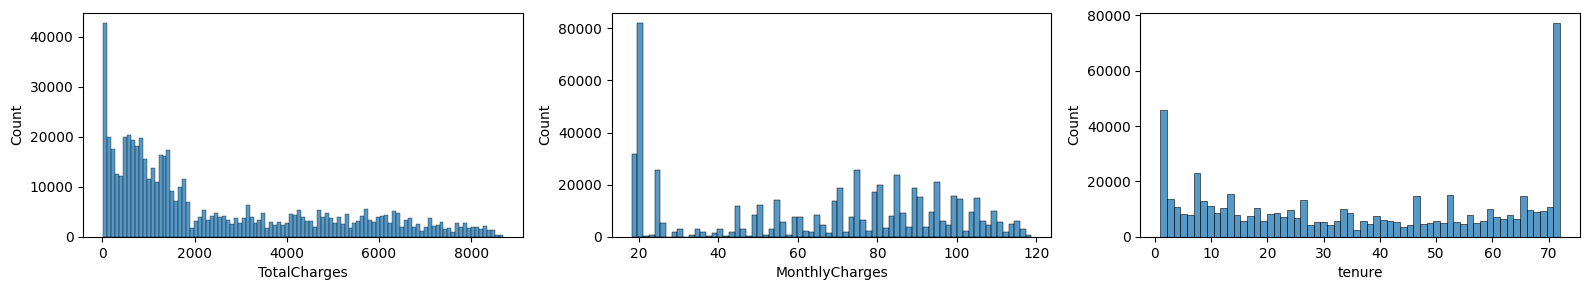

In [21]:
_, axes = plt.subplots(1, 3, figsize = (16, 3))
sns.histplot(df_train, x = 'TotalCharges', ax = axes[0])
sns.histplot(df_train, x = 'MonthlyCharges', ax = axes[1])
sns.histplot(df_train, x = 'tenure', ax = axes[2])
plt.tight_layout()
plt.show()

In [22]:
dict_expr = {
    'gender': (pl.col('gender') == 'Male').cast(pl.Int8),
    'No_Internet': (pl.col('DeviceProtection') == 'No internet service').cast(pl.Int8),
    'DSL_Y': (pl.col('InternetService') == 'DSL').cast(pl.Int8),
}
for i in ['Dependents', 'PaperlessBilling', 'Partner', 'PhoneService']:
    dict_expr[i] = (pl.col(i) == 'Yes').cast(pl.Int8)

for i in ['DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'StreamingMovies', 'StreamingTV', 'TechSupport', 'MultipleLines']:
    dict_expr[i + '_Y'] = (pl.col(i) == 'Yes').cast(pl.Int8)

loader = make_pipeline(
    PolarsLoader(predefined_types={'id': pl.Int64}),
    ExprProcessor(dict_expr=dict_expr),
    PandasConverter(index_col = 'id')
)
# Target은 train만 처리
df_train = loader.fit_transform([data_path / 'train.csv']).assign(
    Churn = lambda x: (x['Churn'] == 'Yes').astype('int8')
)
df_test = loader.transform([data_path / 'test.csv'])

In [23]:
df_data_spec = loader[0].df_type_.join(
    df_train.dtypes.astype(str).rename('actual_dtype'), how = 'outer'
).pipe(lambda x: x.loc[x['actual_dtype'].notna()]).sort_index().sort_values('actual_dtype')
display(df_data_spec)
df_train.shape, df_test.shape

,min,max,na,count,n_unique,dtype,f32,i32,i16,i8,actual_dtype
MultipleLines,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
StreamingMovies,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
OnlineSecurity,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
OnlineBackup,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
StreamingTV,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
InternetService,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
PaymentMethod,NaN,NaN,0.0,594194.0,4.0,String,False,False,False,False,category
DeviceProtection,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
Contract,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category
TechSupport,NaN,NaN,0.0,594194.0,3.0,String,False,False,False,False,category


((594194, 29), (254655, 28))

In [24]:
X_bin = ['Dependents', 'PaperlessBilling', 'Partner', 'PhoneService', 'gender', 'SeniorCitizen', ]
X_tri = ['DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'StreamingMovies', 'StreamingTV', 'TechSupport']
X_bin2 = ['{}_Y'.format(i) for i in X_tri] + ['No_Internet', 'DSL_Y', 'MultipleLines_Y']
X_tri.append('InternetService')
X_tri.append('MultipleLines')
X_num = ['TotalCharges', 'MonthlyCharges', 'tenure']
X_nom = ['PaymentMethod', 'Contract']

set(df_data_spec.index) - set(X_bin + X_tri + X_bin2 + X_nom + X_num)

{'Churn'}